This note book uses the previously fine-tuned CNN model for the TasselNet to train a CNN LSTM model.

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
import matplotlib.pyplot as plt

2025-03-04 12:25:44.630642: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-04 12:25:45.001617: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-04 12:25:45.001689: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-04 12:25:45.085177: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-04 12:25:45.191973: I tensorflow/core/platform/cpu_feature_guar

In [2]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# Need to first locate the train data and stack them to be used in the network

# the train blocks are 101, 102, 203, and 301

# We also need the validation data, but since it is block 204, we can leave that data as it is

# Stacking the train data might take a lot of memory, and we might have to stack it in a job

# Let's try it here initially though

# location of all data
all_data_loc = 'All_data'

# train blocks
train_blocks = ['block_0101', 'block_0102', 'block_0203', 'block_0301']

In [4]:
# get the density maps and the corresponding image subwindows so that they can be stacked for the train data
all_feature_subwindow_names = []
all_density_map_names =[]

for folder_name in train_blocks:
    path_name = os.path.join(all_data_loc, folder_name)
    density_map = [file for file in os.listdir(path_name)if file[:7] == 'density']
    feature_map = [file for file in os.listdir(path_name)if file[:7] == 'subwind']
    all_feature_subwindow_names.append(feature_map)
    all_density_map_names.append(density_map)
    

In [5]:
# load all feature maps
all_feature_maps = []
counter = 0
for item in np.array(all_feature_subwindow_names).flatten():
    load_map = np.load(os.path.join(all_data_loc, train_blocks[counter], item))
    all_feature_maps.append(load_map)
    counter = counter + 1

In [6]:
# load density maps
all_density_maps = []
counter = 0
for map in np.array(all_density_map_names).flatten():
    load_density_map = np.load(os.path.join(all_data_loc, train_blocks[counter], map))
    all_density_maps.append(load_density_map)
    counter = counter + 1

In [7]:
# check the shape of an item
all_density_maps[0].shape, all_feature_maps[0].shape

((12288, 7), (12288, 13, 32, 32, 3))

In [8]:
# how many items in each list?
len(all_density_maps), len(all_feature_maps)

(4, 4)

In [9]:
# stack all data together?

# I think we need to stack vertically
all_train_density_maps = np.vstack(all_density_maps)

all_train_feature_maps = np.vstack(all_feature_maps)

In [10]:
# check these shapes
all_train_density_maps.shape, all_train_feature_maps.shape

((49152, 7), (49152, 13, 32, 32, 3))

In [11]:
# we may need to do a sanity check to know if we have correctly stacked
for i in range(4):
    print(np.mean(all_density_maps[i] == all_train_density_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [12]:
# for feature maps
for i in range(4):
    print(np.mean(all_feature_maps[i] == all_train_feature_maps[12288*i: 12288 + 12288*i,:]))

1.0
1.0
1.0
1.0


In [13]:
# Okay, we have stacked the data correctly. Let's not store these data separately and proceed with the train script

In [14]:
# Also need to load the validation data

# list the contents in the validation folder
all_valid_contents = os.listdir("All_data/block_0204")

In [15]:
all_valid_contents

['all_np_files',
 'subwindow_seqs_0204.npy',
 '.ipynb_checkpoints',
 'density_maps_seqs_0204.npy']

In [16]:
validation_feature_maps = np.load(os.path.join("All_data/block_0204", 'subwindow_seqs_0204.npy'))

In [17]:
validation_density_map = np.load(os.path.join("All_data/block_0204", 'density_maps_seqs_0204.npy'))

In [18]:
validation_feature_maps.shape, validation_density_map.shape

((12288, 13, 32, 32, 3), (12288, 7))

In [19]:
# Okay, now moving to training the model - this needs to be done in stages. First by freezing all the layers of the pretrained model, and then by unfreezing the high level layers. Let's see how this can be done, let's first write the model architecture.

In [20]:
# load the model after transfer learning - this might be something that we need to change after talking to Dr. G
gmp_model = tf.keras.models.load_model('../../../Spring_2024/Bayes_for_comps/TS_bayes_implementation_for_TN/models/trained_gmp_model_dense_32_new.h5')

2025-03-04 12:26:59.640710: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0


In [21]:
gmp_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 activation (Activation)     (None, None, None, 32)    0         
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 activation_1 (Activation)   (None, None, None, 32)    0         
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 32)    0         
 D)                                                              
                                                           

In [22]:
# Okay, we may need to remove some of these layers and add back some of these layers.

In [23]:
# need to remove some of the last layers
output_trial = gmp_model.layers[-11].output

In [24]:
output_trial

<KerasTensor: shape=(None, None, None, 64) dtype=float32 (created by layer 'max_pooling2d_1')>

In [25]:
# create the functional API model
reduced_model = tf.keras.models.Model(gmp_model.input, output_trial)
reduced_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 activation (Activation)     (None, None, None, 32)    0         
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 activation_1 (Activation)   (None, None, None, 32)    0         
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 32)    0         
 D)                                                              
                                                             

In [26]:
896 + 9248 + 18496

28640

In [27]:
# okay, now need to add back the dropout, the dense and activation

# add dropout
added_dropout = tf.keras.layers.Dropout(0.5, name = "New_dropout_0")(gmp_model.layers[-11].output)

# add global max pooling
added_flatten = tf.keras.layers.GlobalMaxPooling2D()(added_dropout)

# add dense
added_dense = tf.keras.layers.Dense(64, name = "New_Dense_0")(added_flatten)

# add activation
added_Act = tf.keras.layers.Activation('relu', name = "New_Activation_0")(added_dense)

# add dropout
added_dropout2 = tf.keras.layers.Dropout(0.5, name = "New_dropout_1")(added_Act)

# # add another dense
# added_dense_1 = tf.keras.layers.Dense(32, name = "New_Dense_1")(added_dropout2)

# # add activation
# added_Act_1 = tf.keras.layers.Activation('relu', name = "New_Activation_1")(added_dense_1)

# # add dropout
# added_dropout3 = tf.keras.layers.Dropout(0.5, name = "New_dropout_2")(added_Act_1)

# # add pred head
# added_dense_3 = tf.keras.layers.Dense(1, name = "New_Dense_2")(added_dropout3)

# # add activation
# added_Act_2 = tf.keras.layers.Activation('relu', name = "New_Activation_2")(added_dense_3)

# define the new model with functional API
new_model = tf.keras.models.Model(gmp_model.input, added_dropout2)

In [28]:
new_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 activation (Activation)     (None, None, None, 32)    0         
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 activation_1 (Activation)   (None, None, None, 32)    0         
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 32)    0         
 D)                                                              
                                                           

In [29]:
# freeze the layers
for layer in gmp_model.layers:
    layer.trainable = False

In [30]:
new_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 activation (Activation)     (None, None, None, 32)    0         
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 activation_1 (Activation)   (None, None, None, 32)    0         
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 32)    0         
 D)                                                              
                                                           

In [31]:
# input layer
input_layer = tf.keras.layers.Input((None,None,None,3))

In [32]:
time_dist_layer = tf.keras.layers.TimeDistributed(new_model)

time_dist_output = time_dist_layer(input_layer)
time_dist_output

<KerasTensor: shape=(None, None, 64) dtype=float32 (created by layer 'time_distributed')>

In [33]:
lstm_layer = tf.keras.layers.LSTM(64)
lstm_output = lstm_layer(time_dist_output)
lstm_output

<KerasTensor: shape=(None, 64) dtype=float32 (created by layer 'lstm')>

In [34]:
# pred_layer_td = tf.keras.layers.TimeDistributed()
pred_layer = tf.keras.layers.Dense(7, activation = "relu")
# pred_time_dist_layer = tf.keras.layers.TimeDistributed(pred_layer)
pred_layer_out = pred_layer(lstm_output)
pred_layer_out

<KerasTensor: shape=(None, 7) dtype=float32 (created by layer 'dense')>

In [35]:
cnn_lstm = tf.keras.models.Model(input_layer, pred_layer_out)
cnn_lstm.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, Non   0         
                             e, 3)]                              
                                                                 
 time_distributed (TimeDist  (None, None, 64)          69728     
 ributed)                                                        
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 7)                 455       
                                                                 
Total params: 103207 (403.15 KB)
Trainable params: 37639 (147.03 KB)
Non-trainable params: 65568 (256.12 KB)
_________________________________________________________________


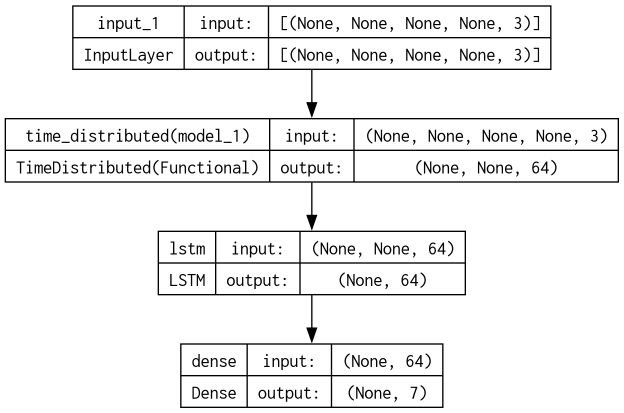

In [36]:
tf.keras.utils.plot_model(cnn_lstm, show_shapes = True)

In [37]:
# Define and add the generator function
def data_generator(x_data, y_data, batch_size, shuffle=False, peek=False, verbose=False):
    num_samples = len(x_data)
    indices = np.arange(num_samples)
    
    if peek:    # Give first batch unshuffled and don't change start index when peeking for training
        end = min(batch_size, num_samples)
        if verbose:
            print(f"Generating peeking batch up to index {end}")
        batch_x = x_data[:end]
        batch_y = y_data[:end]
        peek = False
        yield (batch_x, batch_y)

    while True:    # Loop indefinitely for epochs
        # Shuffle indices at the start of each epoch after the peek, if shuffle is enabled
        if shuffle:
            np.random.shuffle(indices)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]

            # Print batch indices if verbose
            if verbose:
                # Warning: calling verbose when shuffling will usually clutter output
                if shuffle:
                    if len(batch_indices) < 16:
                        print(f"Batch indices: {np.sort(batch_indices)}")
                    else:
                        print(f"Printing batch indices would clutter output. Skipped.")
                    print(f"Length: {len(batch_indices)}")
                else:
                    print(f"Generating batch from index {start} to {end}")
                # traceback.print_stack()

            # Generate batches
            batch_x = x_data[batch_indices]
            batch_y = y_data[batch_indices]

            # Yield the current batch
            yield (batch_x, batch_y)

In [38]:
%%time
batch_size = 64
generator_batch_size = 64
train_gen = data_generator(all_train_feature_maps, all_train_density_maps, batch_size, shuffle=False, peek=True, verbose=False)
val_gen = data_generator(validation_feature_maps, validation_density_map, generator_batch_size, shuffle=False, peek=True, verbose=False)

CPU times: user 4 µs, sys: 6 µs, total: 10 µs
Wall time: 16.2 µs


In [39]:
steps_per_epoch = int(np.ceil(len(all_train_feature_maps) / batch_size))
train_steps = int(np.ceil(len(all_train_feature_maps) / generator_batch_size))
validation_steps = int(np.ceil(len(validation_feature_maps) / generator_batch_size))

In [40]:
%%time
# compile the model
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
cnn_lstm.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])
    
# add early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=10)

# fit the generator - the steps are a must here
history = cnn_lstm.fit(train_gen,
          validation_data = val_gen, steps_per_epoch=steps_per_epoch, 
                                  validation_steps=validation_steps,           
          epochs = 100, callbacks = [es])

Epoch 1/100


2025-03-04 12:27:06.580685: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_2/time_distributed/model_1/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-03-04 12:27:06.881833: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-03-04 12:27:09.347601: I external/local_xla/xla/service/service.cc:168] XLA service 0x154954ad6700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-03-04 12:27:09.347647: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-03-04 12:27:09.408087: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1741112829.768559 3611806 device_compiler.h:186] Compi

768/768 [==============================] - 17s 16ms/step - loss: 0.0280 - mean_absolute_error: 0.0627 - val_loss: 0.0165 - val_mean_absolute_error: 0.0601
Epoch 2/100
768/768 [==============================] - 11s 15ms/step - loss: 0.0262 - mean_absolute_error: 0.0603 - val_loss: 0.0160 - val_mean_absolute_error: 0.0575
Epoch 3/100
768/768 [==============================] - 11s 15ms/step - loss: 0.0258 - mean_absolute_error: 0.0608 - val_loss: 0.0160 - val_mean_absolute_error: 0.0573
Epoch 4/100
768/768 [==============================] - 11s 15ms/step - loss: 0.0255 - mean_absolute_error: 0.0611 - val_loss: 0.0158 - val_mean_absolute_error: 0.0574
Epoch 5/100
768/768 [==============================] - 11s 15ms/step - loss: 0.0252 - mean_absolute_error: 0.0619 - val_loss: 0.0157 - val_mean_absolute_error: 0.0592
Epoch 6/100
768/768 [==============================] - 12s 15ms/step - loss: 0.0251 - mean_absolute_error: 0.0622 - val_loss: 0.0156 - val_mean_absolute_error: 0.0572
Epoch 7/10

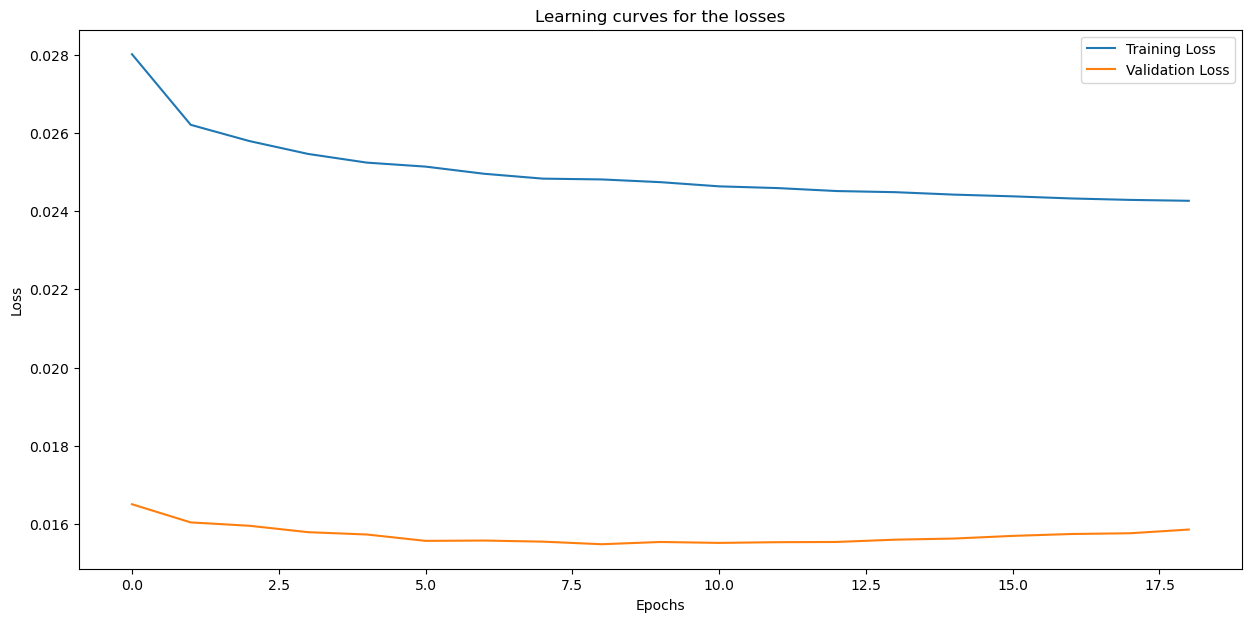

In [41]:
# plot the losses
plt.figure(figsize = (15,7))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Learning curves for the losses")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
# history.history['loss']

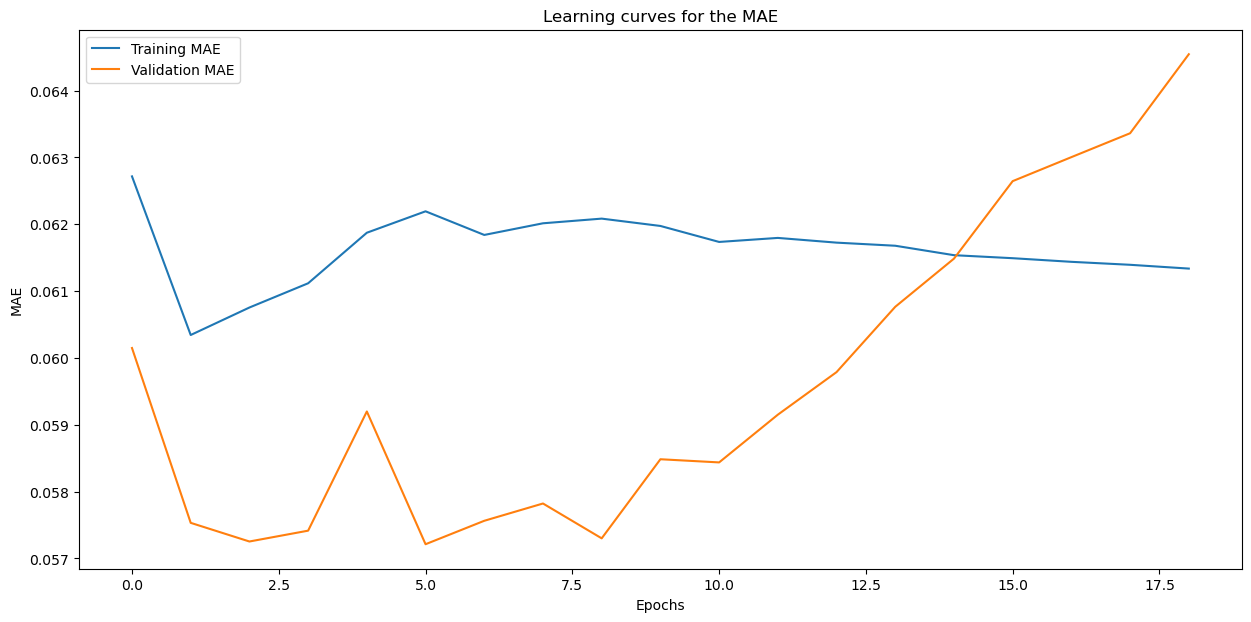

In [42]:
# plot the maes
plt.figure(figsize = (15,7))
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.title("Learning curves for the MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [43]:
# save this model
model_name_frozen = 'pre_trained_CNN_architecture_CNN_LSTM_frozen.keras'
cnn_lstm.save('models' + '/' + model_name_frozen)

In [44]:
# unfreeze some of teh base weights of the CNN models architecture and see if we can get better results.

In [45]:
gmp_model.trainable = True

set_trainable = False

for layer in gmp_model.layers:
    if layer.name == 'conv2d_3':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

In [46]:
new_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv2d (Conv2D)             (None, None, None, 32)    896       
                                                                 
 activation (Activation)     (None, None, None, 32)    0         
                                                                 
 conv2d_1 (Conv2D)           (None, None, None, 32)    9248      
                                                                 
 activation_1 (Activation)   (None, None, None, 32)    0         
                                                                 
 max_pooling2d (MaxPooling2  (None, None, None, 32)    0         
 D)                                                              
                                                           

In [47]:
4160 + 36928

41088

In [48]:
# see if in turn the number of parameters of the CNN LSTM model changed - it has according to the CNN architecture.
cnn_lstm.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, Non   0         
                             e, 3)]                              
                                                                 
 time_distributed (TimeDist  (None, None, 64)          69728     
 ributed)                                                        
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 7)                 455       
                                                                 
Total params: 103207 (403.15 KB)
Trainable params: 74567 (291.28 KB)
Non-trainable params: 28640 (111.88 KB)
_________________________________________________________________


In [49]:
# compile the model and run tis again with the unfrozen base weights of the CNN model.

In [50]:
%%time
# compile the model
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
cnn_lstm.compile(loss='mean_squared_error', optimizer=opt, metrics = ['mean_absolute_error'])
    
# add early stopping
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', restore_best_weights = True, verbose=1, patience=10)

# fit the generator - the steps are a must here
history_new = cnn_lstm.fit(train_gen,
          validation_data = val_gen, steps_per_epoch=steps_per_epoch, 
                                  validation_steps=validation_steps,           
          epochs = 100, callbacks = [es])

Epoch 1/100


2025-03-04 12:30:52.777245: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_2/time_distributed/model_1/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


768/768 [==============================] - 15s 16ms/step - loss: 0.0247 - mean_absolute_error: 0.0616 - val_loss: 0.0166 - val_mean_absolute_error: 0.0693
Epoch 2/100
768/768 [==============================] - 12s 16ms/step - loss: 0.0246 - mean_absolute_error: 0.0615 - val_loss: 0.0168 - val_mean_absolute_error: 0.0722
Epoch 3/100
768/768 [==============================] - 12s 16ms/step - loss: 0.0244 - mean_absolute_error: 0.0613 - val_loss: 0.0170 - val_mean_absolute_error: 0.0738
Epoch 4/100
768/768 [==============================] - 12s 16ms/step - loss: 0.0244 - mean_absolute_error: 0.0613 - val_loss: 0.0172 - val_mean_absolute_error: 0.0759
Epoch 5/100
768/768 [==============================] - 12s 16ms/step - loss: 0.0243 - mean_absolute_error: 0.0611 - val_loss: 0.0172 - val_mean_absolute_error: 0.0757
Epoch 6/100
768/768 [==============================] - 12s 16ms/step - loss: 0.0241 - mean_absolute_error: 0.0607 - val_loss: 0.0172 - val_mean_absolute_error: 0.0755
Epoch 7/10

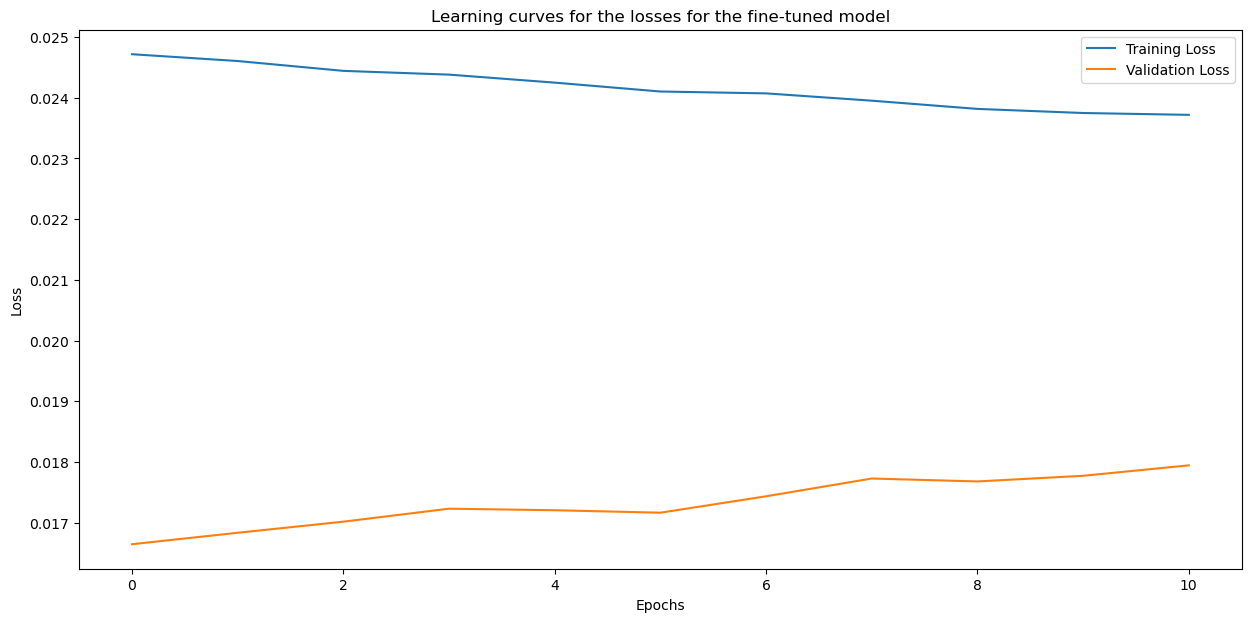

In [51]:
# plot the losses
plt.figure(figsize = (15,7))
plt.plot(history_new.history['loss'], label='Training Loss')
plt.plot(history_new.history['val_loss'], label='Validation Loss')
plt.title("Learning curves for the losses for the fine-tuned model")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

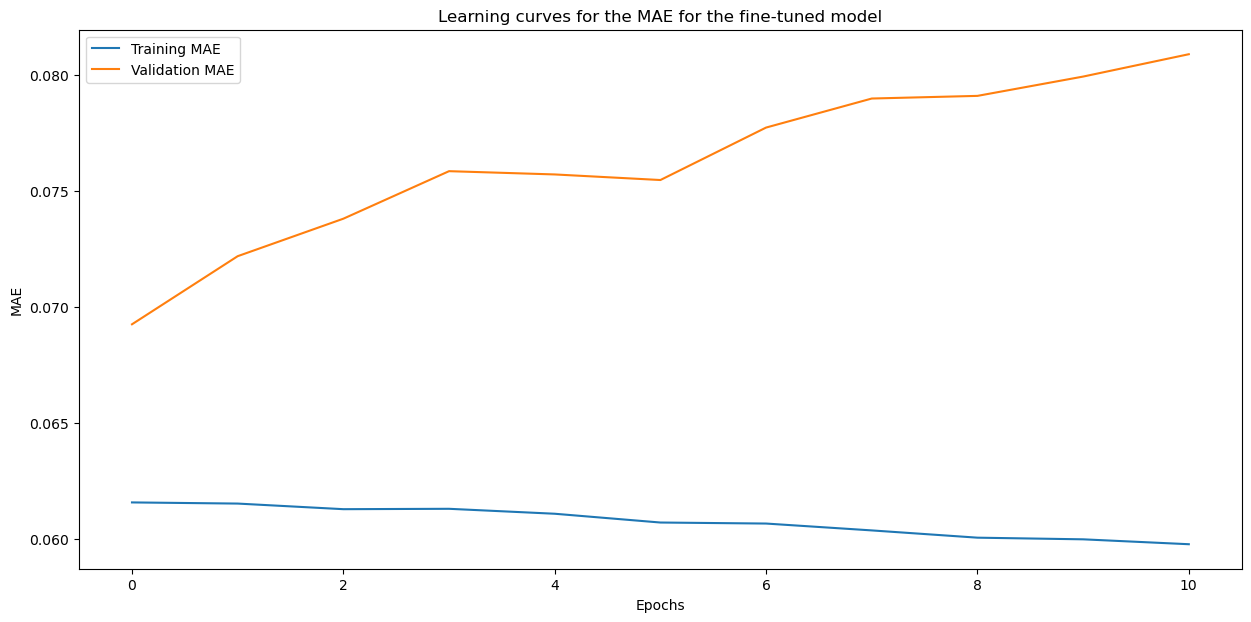

In [52]:
plt.figure(figsize = (15,7))
plt.plot(history_new.history['mean_absolute_error'], label='Training MAE')
plt.plot(history_new.history['val_mean_absolute_error'], label='Validation MAE')
plt.title("Learning curves for the MAE for the fine-tuned model")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [53]:
# save this model
model_name_finetuned = 'pre_trained_CNN_architecture_CNN_LSTM_finetuned.keras'
cnn_lstm.save('models' + '/' + model_name_finetuned)

In [54]:
# unfreezing the weights of the CNN model does not seem to help much with the model training. When evaluating we should probably use both models and see if ne performs better than the other as it is difficult to decide now since we are working on a subwindow scale. 